In [233]:
from tensorflow.keras.models import Sequential,Model
from tensorflow.keras.layers import Dense, Input, LSTM

In [234]:
model = Sequential()
model.add(Input(shape=(5,1)))
model.add(LSTM(2, return_sequences=True))#input is 2 now 3 is hidden so 4(3*2+2)
model.summary()

Model: "sequential_39"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_50 (LSTM)                  │ (None, 5, 2)           │            32 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 32 (128.00 B)

 Trainable params: 32 (128.00 B)

 Non-trainable params: 0 (0.00 B)

In [235]:
import pandas as pd
df = pd.read_csv('/content/TCS.csv', parse_dates=['Date '],index_col='Date ',date_format='%d-%b-%y')
df.head()

,OPEN
Date,
2024-06-05,3716.0
2024-06-06,3781.0
2024-06-07,3837.3
2024-06-10,3895.0
2024-06-11,3845.0


In [236]:
df.columns

Index(['OPEN '], dtype='object')

In [237]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 248 entries, 2024-06-05 to 2025-06-04
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   OPEN    248 non-null    float64
dtypes: float64(1)
memory usage: 3.9 KB


In [238]:
data = df['OPEN '].values.reshape(-1,1)
data.shape

(248, 1)

In [239]:
import numpy as np
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler(feature_range=(0,1))
data = scaler.fit_transform(data)

In [240]:
284*.8

227.20000000000002

In [241]:
train_data = data[:227]
test_data = data[227:]

Arrange train and test data as timestamp. In our case 5 timestamp

In [258]:
ts = 3
X_train = []
y_train = []
X_test = []
y_test = []
for i in range(ts,len(train_data)):
  X_train.append(train_data[i-ts:i])
  y_train.append(train_data[i])
for i in range(ts,len(test_data)):
  X_test.append(test_data[i-ts:i])
  y_test.append(test_data[i])
X_train,y_train = np.array(X_train),np.array(y_train)
X_test,y_test = np.array(X_test),np.array(y_test)
print(X_train.shape,y_train.shape)
print(X_test.shape,y_test.shape)

(224, 3, 1) (224, 1)
(18, 3, 1) (18, 1)


In [259]:
model = Sequential()
model.add(Input(shape=(7,1)))
model.add(LSTM(units =5, return_sequences=True))
model.add(LSTM(3))
model.add(Dense(1))#we didn't take activation function beacuse we're finding absoulate value
model.summary()

Model: "sequential_49"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_69 (LSTM)                  │ (None, 7, 5)           │           140 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_70 (LSTM)                  │ (None, 3)              │           108 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_34 (Dense)                │ (None, 1)              │             4 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 252 (1008.00 B)

 Trainable params: 252 (1008.00 B)

 Non-trainable params: 0 (0.00 B)

In [261]:
from tensorflow.keras.optimizers import Adam
model.compile(optimizer=Adam(learning_rate=0.001),loss='mse')
model.fit(X_train,y_train,epochs=50,batch_size=32,
          validation_data=(X_test,y_test),verbose=1)

Epoch 1/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 87ms/step - loss: 0.0237 - val_loss: 0.0548
Epoch 2/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0213 - val_loss: 0.0495
Epoch 3/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0196 - val_loss: 0.0448
Epoch 4/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0177 - val_loss: 0.0423
Epoch 5/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0174 - val_loss: 0.0378
Epoch 6/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0137 - val_loss: 0.0313
Epoch 7/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0144 - val_loss: 0.0278
Epoch 8/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0125 - val_loss: 0.0257
Epoch 9/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0095 - val_loss: 0.0213
Epoch 10/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0094 - val_loss: 0.0160
Epoch 11/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0096 - val_loss: 0.0147
Epoch 12/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0075 - val_loss: 0.0118
E

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 486ms/step


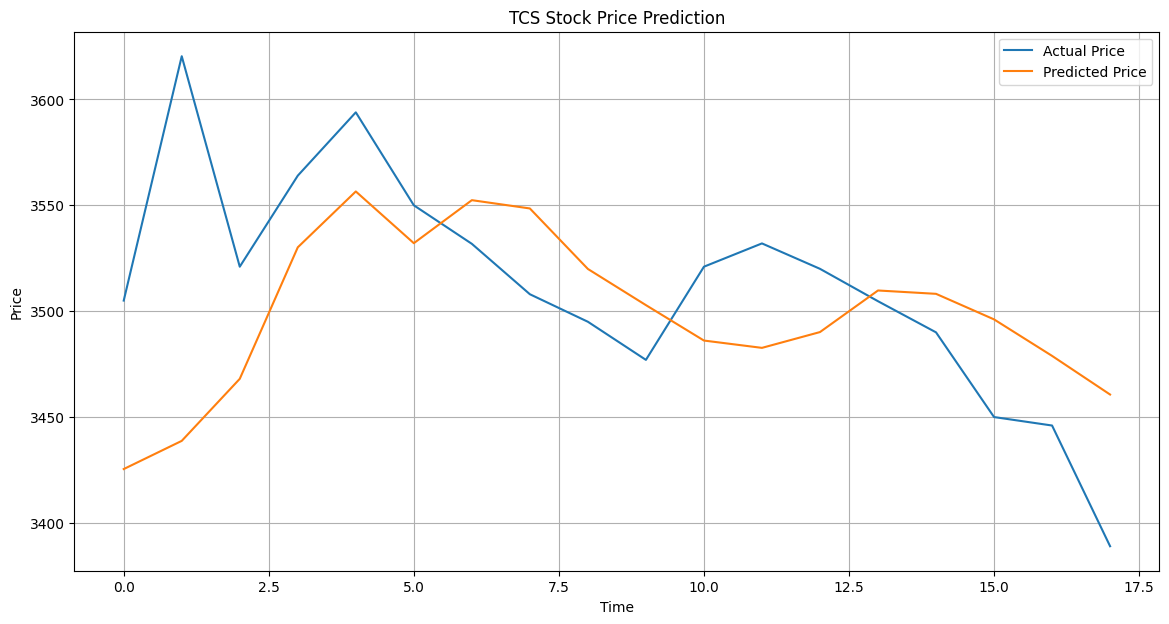

In [262]:
import matplotlib.pyplot as plt
y_pred = model.predict(X_test)
# Reshape y_pred to match y_test shape (samples, features) by taking the last time step's prediction
predicted_prices = scaler.inverse_transform(y_pred)
actual_prices = scaler.inverse_transform(y_test)
plt.figure(figsize=(14,7))
plt.plot(actual_prices,label='Actual Price')
plt.plot(predicted_prices,label='Predicted Price')
plt.title('TCS Stock Price Prediction')
plt.xlabel('Time')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.show()

In [246]:
 y_pred = model.predict(X_test)
y_pred.shape

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step


(14, 1)

In [247]:
y_pred

array([[0.4178787 ],
       [0.43110713],
       [0.44166815],
       [0.45460248],
       [0.45671827],
       [0.44818315],
       [0.44588435],
       [0.44035107],
       [0.43341008],
       [0.43055505],
       [0.42913237],
       [0.4290508 ],
       [0.42806622],
       [0.4267939 ]], dtype=float32)

Take only 1 prediction at a time  Take the actual data for that day in training, train the model again and again predict only for 1 day at a time

In [248]:
y_train.shape,y_test.shape,X_train.shape,X_test.shape

((220, 1), (14, 1), (220, 7, 1), (14, 7, 1))

In [257]:
from typing_extensions import final
model = Sequential()
X = Input(shape=(7,1))
lstm1_output,final_memory_state, final_carry_state = \
LSTM(units =10, return_sequences=True, return_state=True)(X)

lstm2 = LSTM(units =3,return_state=True)
whole_seq_output= lstm2(lstm1_output, initial_state = [final_memory_state,
                                                       final_carry_state])
d1 = Dense(1)(whole_seq_output[0])
model = Model(inputs=X,outputs=d1)
model.summary()

Model: "functional_63"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_48      │ (None, 7, 1)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_67 (LSTM)      │ [(None, 7, 10),   │        480 │ input_layer_48[0… │
│                     │ (None, 10),       │            │                   │
│                     │ (None, 10)]       │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_68 (LSTM)      │ [(None, 3),       │        168 │ lstm_67[0][0],    │
│                     │ (None, 3), (None, │            │ lstm_67[0][1],    │
│                     │ 3)]               │            │ lstm_67[0][2]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_33 (Dense)    │ (None, 1)         │          4 │ lstm_68[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 652 (2.55 KB)

 Trainable params: 652 (2.55 KB)

 Non-trainable params: 0 (0.00 B)